In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
from huggingface_hub import login
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

import mlflow

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-11-28 21:51:07.299203: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-28 21:51:07.311741: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-28 21:51:07.315785: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-28 21:51:07.325781: I tensorflow/core/platfor

INFO 11-28 21:51:09 [__init__.py:239] Automatically detected platform cuda.


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
model_name = "ModernBERT-large"
developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "transformer"

test_data_full_cleaned_path = current_dir.parent.parent / "data/01_processed/pan21-authorship-verification-test-cleaned.jsonl"

Load environment variables
Get access to HuggingFace

In [6]:
load_dotenv(env_path)
huggingface_acess_token = os.getenv("huggingface_jp")

In [7]:
!nvidia-smi

Fri Nov 28 21:51:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 PCIe               Off |   00000000:61:00.0 Off |                    0 |
| N/A   53C    P0             54W /  310W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [8]:
gpu_name = torch.cuda.get_device_name(0)
gpu_props = torch.cuda.get_device_properties(0)
gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)  # in GB

In [9]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

188

In [10]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Classification parameters

In [11]:
classification_threshold = 0.95

# Load dataset

In [12]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:01<00:00, 525MB/s] 


Successfully loaded 19999 items.


In [13]:
test_data_df = pd.DataFrame(test_data)
print(test_data_df.head(3))

                                     id  \
0  c28e8b03-c02a-5184-b58a-12dd28b8ca74   
1  b9326101-6352-56dd-9d1b-1f41466897b7   
2  e2ac4453-bf54-53f2-bf68-6caae6aacded   

                                                pair   same  
0  [talk because they hadnt been exposed to commu...   True  
1  [Zazuki nodded his head and got to his feet, k...   True  
2  [Oh we did lots of special things On Christmas...  False  


In [14]:
test_data_full_reduced_df =  test_data_df.head(1000)
print(test_data_df.head())

                                     id  \
0  c28e8b03-c02a-5184-b58a-12dd28b8ca74   
1  b9326101-6352-56dd-9d1b-1f41466897b7   
2  e2ac4453-bf54-53f2-bf68-6caae6aacded   
3  a5e9a289-0999-5764-b597-dc1bf8c21ede   
4  cb4054b1-d422-58d6-a137-dcfc70100df6   

                                                pair   same  
0  [talk because they hadnt been exposed to commu...   True  
1  [Zazuki nodded his head and got to his feet, k...   True  
2  [Oh we did lots of special things On Christmas...  False  
3  [Hey now, at least Shido brings home some mone...   True  
4  [It was a mere five minutes walk from third ye...   True  


# Set up model

Log in to huggingface

In [15]:
login(huggingface_acess_token)

Load the model

In [16]:
model_id = "answerdotai/ModernBERT-large"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id)

Set the processing to GPU

In [17]:
model = model.to("cuda")

In [18]:
model.eval()

ModernBertModel(
  (embeddings): ModernBertEmbeddings(
    (tok_embeddings): Embedding(50368, 1024, padding_idx=50283)
    (norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.0, inplace=False)
  )
  (layers): ModuleList(
    (0): ModernBertEncoderLayer(
      (attn_norm): Identity()
      (attn): ModernBertAttention(
        (Wqkv): Linear(in_features=1024, out_features=3072, bias=False)
        (rotary_emb): ModernBertRotaryEmbedding()
        (Wo): Linear(in_features=1024, out_features=1024, bias=False)
        (out_drop): Identity()
      )
      (mlp_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (mlp): ModernBertMLP(
        (Wi): Linear(in_features=1024, out_features=5248, bias=False)
        (act): GELUActivation()
        (drop): Dropout(p=0.0, inplace=False)
        (Wo): Linear(in_features=2624, out_features=1024, bias=False)
      )
    )
    (1-27): 27 x ModernBertEncoderLayer(
      (attn_norm): LayerNorm((1024,), eps

# Evaluate model

Evaluation function

In [19]:
def evaluate_results(y_test, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_test, y_pred)*100, 2)
    precision = round(precision_score(y_test, y_pred, average=average)*100, 2)
    recall = round(recall_score(y_test, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_test, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Evaluate model function

In [20]:
def compute_similarities(test_data_df, model):
    start_time = time.time()
    verification_results = []
    
    def mean_pooling(model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        expanded_mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        summed = torch.sum(token_embeddings * expanded_mask, dim=1)
        counts = torch.clamp(expanded_mask.sum(dim=1), min=1e-9)
        return summed / counts

    def get_embedding(text: str):
        encoded = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding= False,
            max_length=8192,
        ).to("cuda")
        
        with torch.no_grad():
            output = model(**encoded)
            embedding = mean_pooling(output, encoded["attention_mask"])
            embedding = F.normalize(embedding, p=2, dim=1)  
        return embedding.cpu()

    for i in tqdm(test_data_df.index, desc="Processing rows"):
        resulting_df_row = {}
        resulting_df_row['id']  = test_data_df.loc[i, 'id']
        resulting_df_row['actual_result'] = test_data_df.loc[i, 'same']
        text1 = test_data_df.loc[i, 'pair'][0]
        text2 = test_data_df.loc[i, 'pair'][1]
        
        text1_embedding = get_embedding(text1)
        text2_embedding = get_embedding(text2)

        cosine_similarity_score = cosine_similarity(text1_embedding, text2_embedding)
        resulting_df_row['cosine_similarity'] = cosine_similarity_score
        verification_results.append(resulting_df_row)

    result_df = pd.DataFrame(verification_results)
    print("--- Execution Time: %s seconds ---" % round(time.time() - start_time, 2))

    return result_df

Compute similarities

Optimal threshold search

Evaluate llama

In [21]:
result_df = evaluate_model(test_data_df, model)

Processing rows:   0%|          | 1/19999 [00:02<12:00:43,  2.16s/it]

[[0.95305175]]


Processing rows:   0%|          | 2/19999 [00:02<7:00:39,  1.26s/it] 

[[0.9793959]]


Processing rows:   0%|          | 3/19999 [00:03<5:23:06,  1.03it/s]

...

[[0.9210427]]


Processing rows: 100%|█████████▉| 19998/19999 [3:54:42<00:00,  1.38it/s]

[[0.97301435]]


Processing rows: 100%|██████████| 19999/19999 [3:54:43<00:00,  1.42it/s]

[[0.9728112]]
--- Execution Time: 14083.07 seconds ---


In [22]:
cleaned_result_df = result_df.dropna()

In [23]:
y_test = cleaned_result_df['actual_result'].to_list()
y_pred = cleaned_result_df['prediction'].to_list()

Calculate the evaluation metrics

In [24]:
accuracy, precision, recall, f1 = evaluate_results(y_test, y_pred)
print(f"The results of evaluation are: \n Accuracy: {accuracy} \n Precision: {precision} \n Recall: {recall} \n F1 score: {f1}")

The results of evaluation are: 
 Accuracy: 61.91 
 Precision: 57.29 
 Recall: 93.59 
 F1 score: 71.07


Create the confusion matrix

Text(0.5, 1.0, 'Confusion Matrix: answerdotai/ModernBERT-large')

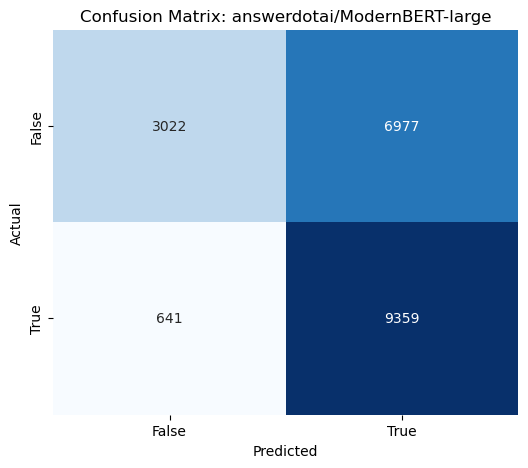

In [25]:
labels = [False, True] 
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=labels, 
            yticklabels=labels, 
            ax=ax,
            cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {model_id}')

Log model information + metrics + results table + confusion matrix

In [27]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")
mlflow.set_experiment("JP-Authorship-Verification")
with mlflow.start_run(run_name=f"{results_path} / {date_str}_{developer_initials}_{model_name}_results"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("model_id ", model_id )
    mlflow.log_param("classification_type", "embedding similarity without fine-tuning")
    mlflow.log_param("classification_threshold", classification_threshold)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)

    mlflow.log_table(data=result_df, artifact_file="results.json")

    mlflow.log_figure(fig, "confusion_matrix.png")